This code imports all necessary libraries for the project:

-> NumPy for numerical operations.

-> Matplotlib and Seaborn for data visualization.

-> Keras for building neural networks.

-> Scikit-learn for evaluation metrics. Also, it sets a seed for reproducibility using np.random.seed(0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(0)

### Load dataset

This code loads the MNIST dataset (handwritten digits 0–9), splits it into training and testing sets (80% for training, 20% for testing), and prints the shapes of the resulting arrays.

In [ ]:
from keras.datasets import mnist
from sklearn.model_selection import train_test_split

(x, y), (_, _) = mnist.load_data()  # Load ONLY TRAINING data

# Split the data into training and testing sets (80-20 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42) #random_state makes the split consistent.

# Printing shapes to verify
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (48000, 28, 28)
y_train shape: (48000,)
x_test shape: (12000, 28, 28)
y_test shape: (12000,)


### Visualize data

This code visualizes one example image for each digit (0–9) from the training dataset. It helps to understand what the digits look like and ensures the data is loaded correctly.

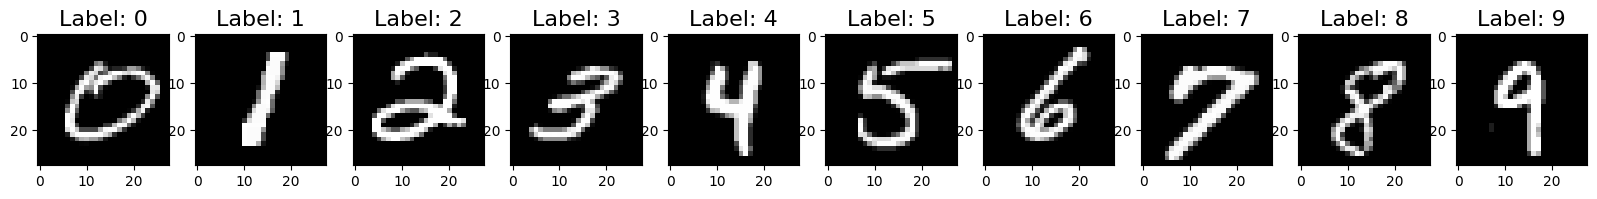

In [ ]:
num_classes = 10
f, ax = plt.subplots(1, num_classes, figsize=(20,20))

for i in range(0, num_classes):
  sample = x_train[y_train == i][0]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title('Label: {}'.format(i), fontsize=16)

This prints the first 10 labels from the y_train dataset. These are still in their original integer format (e.g., 0 to 9) before being one-hot encoded.

In [ ]:
for i in range(10):
  print(y_train[i])

5
0
1
6
1
3
8
8
1
8


### Prepare data

This cell converts the class labels into one-hot encoded vectors, which is a standard format required for training classification models in neural networks.

In [ ]:
# one-hot vector encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

After one-hot encoding, this cell prints the first 10 transformed labels. It's a way to verify that the encoding worked correctly.

In [ ]:
for i in range(10):
  print(y_train[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


This code normalizes image pixel values to a 0–1 range by dividing by 255, which improves model training efficiency and stability.

In [ ]:
# Normalize data
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

This returns the shape of the first training image. For MNIST, the shape is usually (28, 28), indicating a 28x28 pixel grayscale image.

In [ ]:
# shape of training images
x_train[0].shape

(28, 28)

### Create model- Neural Network

This code defines a neural network model with two hidden layers (128 units each, ReLU activation), a dropout layer (25% rate), and a softmax output layer for classification, then compiles it using Adam optimizer and categorical cross-entropy loss. The model.summary() shows the model architecture.

In [ ]:
model = tf.keras.Sequential()

model.add(layers.Conv2D(filters=32, kernel_size=(5,5), padding='Same',
                       activation=tf.nn.relu, input_shape = (28,28,1)))
model.add(layers.Conv2D(filters=32, kernel_size=(5,5), padding='Same',
                       activation=tf.nn.relu))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))


model.add(layers.Conv2D(filters=64, kernel_size=(3,3), padding='Same',
                       activation=tf.nn.relu, input_shape = (28,28,1)))
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), padding='Same',
                       activation=tf.nn.relu))
model.add(layers.MaxPool2D(pool_size=(2,2),strides=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(256,activation=tf.nn.relu))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(10,activation=tf.nn.softmax))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Defining Optimizer
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08, decay=0.0)

#Compiling Model
model.compile(optimizer = optimizer, loss='categorical_crossentropy',
             metrics=["accuracy"])

#Setting Learning rate annealer
learning_rate_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_acc',
                                           patience=3,
                                           verbose=1,
                                           factor=0.5,
                                           min_lr=0.00001)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,530 (3.39 MB)

 Trainable params: 887,530 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

### Train the model

This code trains the model on the x_train data and y_train labels using a batch size of 512 and for 10 epochs, updating the model's weights after each batch.

In [ ]:
batch_size = 112
epochs = 30
model.fit(x = x_train, y=y_train, batch_size = batch_size, epochs=epochs)

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 307s 710ms/step - accuracy: 0.8346 - loss: 0.4974
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 321s 708ms/step - accuracy: 0.9806 - loss: 0.0618
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 323s 710ms/step - accuracy: 0.9854 - loss: 0.0457
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 319s 704ms/step - accuracy: 0.9893 - loss: 0.0353
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 323s 706ms/step - accuracy: 0.9913 - loss: 0.0288
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 321s 703ms/step - accuracy: 0.9924 - loss: 0.0274
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 323s 705ms/step - accuracy: 0.9938 - loss: 0.0214
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 322s 705ms/step - accuracy: 0.9945 - loss: 0.0191
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 321s 703ms/step - accuracy: 0.9941 - loss: 0.0191
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 302s 704ms/step - accuracy: 0.9954 - loss: 0.0162
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 324s 710ms/step - accuracy: 0.9948 - loss: 0.0159
Epoch 12

### Evaluate Model performance (with training data)

This code evaluates the trained model on the test data (x_test and y_test), calculating the test loss and accuracy, then prints the results.

In [ ]:
test_loss,test_acc = model.evaluate(x_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9934 - loss: 0.0509
Test Loss: 0.049321796745061874
Test Accuracy: 0.9931666851043701


This code generates predictions (y_pred) from the model on the test data (x_test), then converts the predicted probabilities into class labels (y_pred_classes) using np.argmax to select the class with the highest probability. Finally, it prints both the predicted probabilities and the class labels.

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred)
print(y_pred_classes)

375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step
[[2.10924742e-28 7.90464166e-25 8.11063741e-25 ... 9.99999940e-01
  3.52409126e-26 1.07658525e-17]
 [0.00000000e+00 4.56384497e-30 8.68871709e-30 ... 1.04027502e-24
  2.01998235e-26 3.62668528e-29]
 [2.81916032e-35 1.25674007e-34 2.18776455e-27 ... 0.00000000e+00
  9.99999940e-01 3.28013141e-26]
 ...
 [5.41597622e-24 9.81960333e-17 5.97075607e-21 ... 3.65197221e-18
  4.81501226e-16 9.99999940e-01]
 [5.41070932e-13 2.77464129e-18 5.91330451e-18 ... 9.99999940e-01
  2.57651355e-16 1.05344821e-11]
 [2.85110029e-18 3.03311086e-22 9.99999940e-01 ... 8.88604371e-16
  5.34403145e-21 9.34756340e-21]]
[7 3 8 ... 9 7 2]


This code selects a random test sample, compares its predicted class (y_sample_pred_class) with the true class (y_sample_true), and displays the sample image (reshaped into a 28x28 format) with a title showing the predicted and true labels. The image is shown in grayscale.

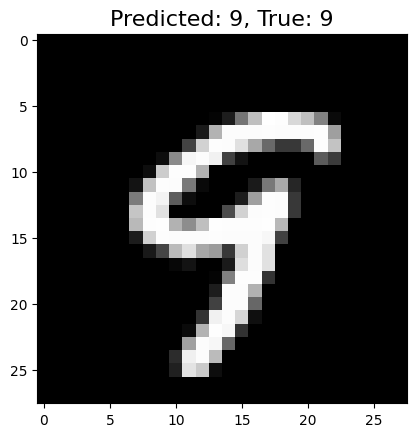

In [ ]:
# Single Example
random_idx = np.random.choice(len(x_test))
x_sample = x_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title('Predicted: {}, True: {}'.format(y_sample_pred_class, y_sample_true),
          fontsize=16)
plt.imshow(x_sample.reshape(28,28), cmap='gray')

### Loading actual test data form dataset

This code loads the MNIST dataset, flattens the test images (X_test) into 1D arrays, and normalizes the pixel values to the range [0, 1]. It also converts the test labels (Y_test) into one-hot encoded vectors using keras.utils.to_categorical, with the specified number of output classes (num_classes).

In [ ]:
# Load the MNIST dataset
(_, _), (X_test, Y_test) = mnist.load_data()

# one-hot vector encoding
Y_test = keras.utils.to_categorical(Y_test, num_classes)

This code evaluates the model's performance on the test data (X_test_flattened and Y_test), calculating the loss and accuracy, and then prints the results.

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, Y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.9875 - loss: 18.5539
Test Loss: 16.5804
Test Accuracy: 0.9892


his code predicts the class probabilities (y_pred) for the test data and converts them into class labels (y_pred_classes) by selecting the class with the highest probability. It then prints both.

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred)
print(y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step
[[0.         0.         0.         ... 0.99999994 0.         0.        ]
 [0.         0.         0.99999994 ... 0.         0.         0.        ]
 [0.         0.99999994 0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
[7 2 1 ... 4 5 6]


This code selects a random test sample, compares its predicted class (y_sample_pred_class) with the true class (y_sample_true), and displays the sample image (reshaped into 28x28) with a title showing both the predicted and true labels in grayscale.

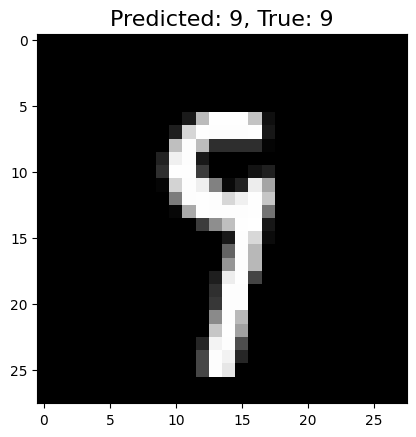

In [ ]:
# Single Example
random_idx = np.random.choice(len(X_test))
x_sample = X_test[random_idx]
y_true = np.argmax(Y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title('Predicted: {}, True: {}'.format(y_sample_pred_class, y_sample_true),
          fontsize=16)
plt.imshow(x_sample.reshape(28,28), cmap='gray')

### Confusion Matrix
Most digits are classified with high accuracy (large numbers on the diagonal)
Some minor confusion exists between visually similar digits

Like 3, 5, and 8 which can look structurally similar
Or 4 and 9 which might have comparable shapes

This code computes the confusion matrix between the true labels (y_true) and predicted labels (y_pred_classes), and then visualizes it using a heatmap with annotations. The plot is labeled with "Predicted Label" and "True Label."

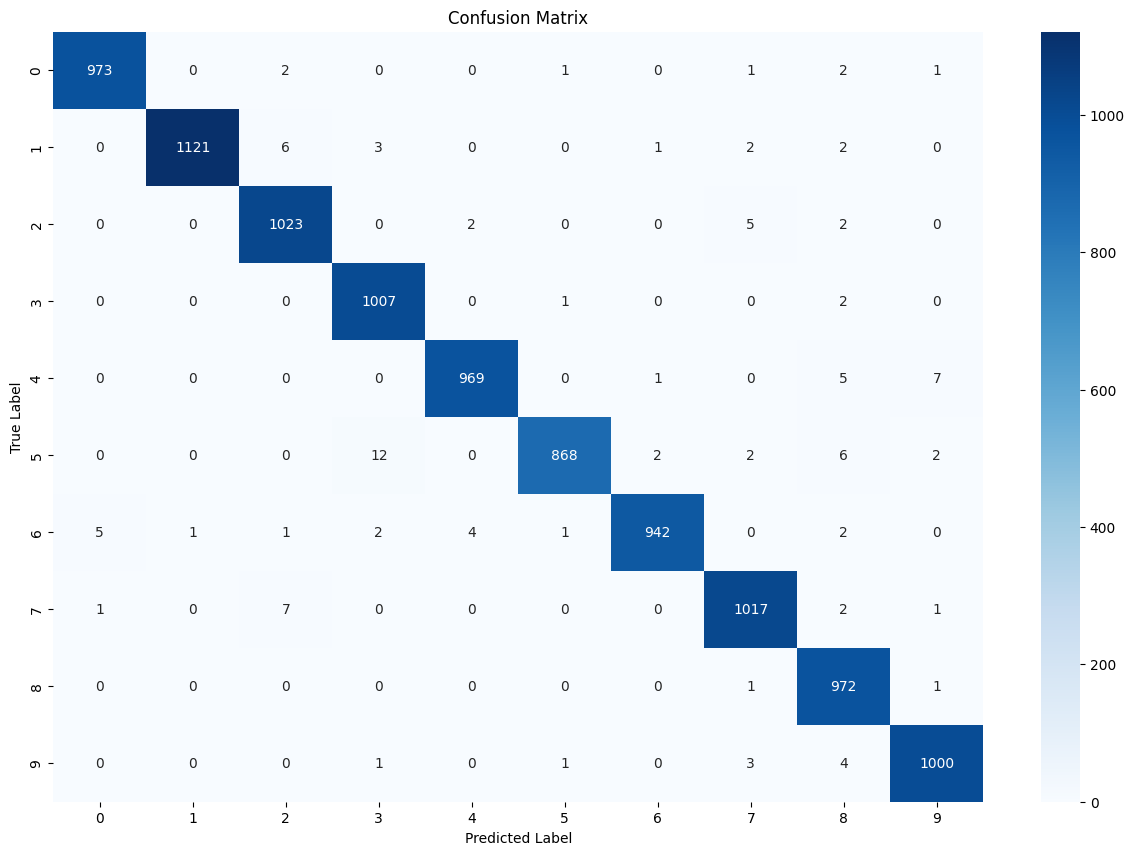

In [ ]:
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap=plt.cm.Blues)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix');

### Investigate errors

This code identifies the errors in predictions by comparing the predicted labels (y_pred_classes) with the true labels (y_true), and then extracts the erroneous predictions, their corresponding probabilities, true labels, and the respective test samples from X_test_flattened.

In [ ]:
errors = (y_pred_classes - y_true != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_pred_errors = y_pred[errors]
y_true_errors = y_true[errors]
x_test_errors = X_test[errors]

This code calculates the difference between the predicted and true probabilities for errors, sorts them, and selects the top 5 largest differences. These indices represent the most confidently incorrect predictions.

In [ ]:
y_pred_errors_probability = np.max(y_pred_errors, axis=1)
true_probability_errors = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))
diff_errors_pred_true = y_pred_errors_probability - true_probability_errors

# Get list of indices of sorted differences
sorted_idx_diff_errors = np.argsort(diff_errors_pred_true)
top_idx_diff_errors = sorted_idx_diff_errors[-5:] # Last 5 ones

This code visualizes the top 5 most confidently incorrect predictions by displaying the corresponding test images, along with their predicted and true labels, using subplots. Each image is shown with a title indicating the predicted and true labels.

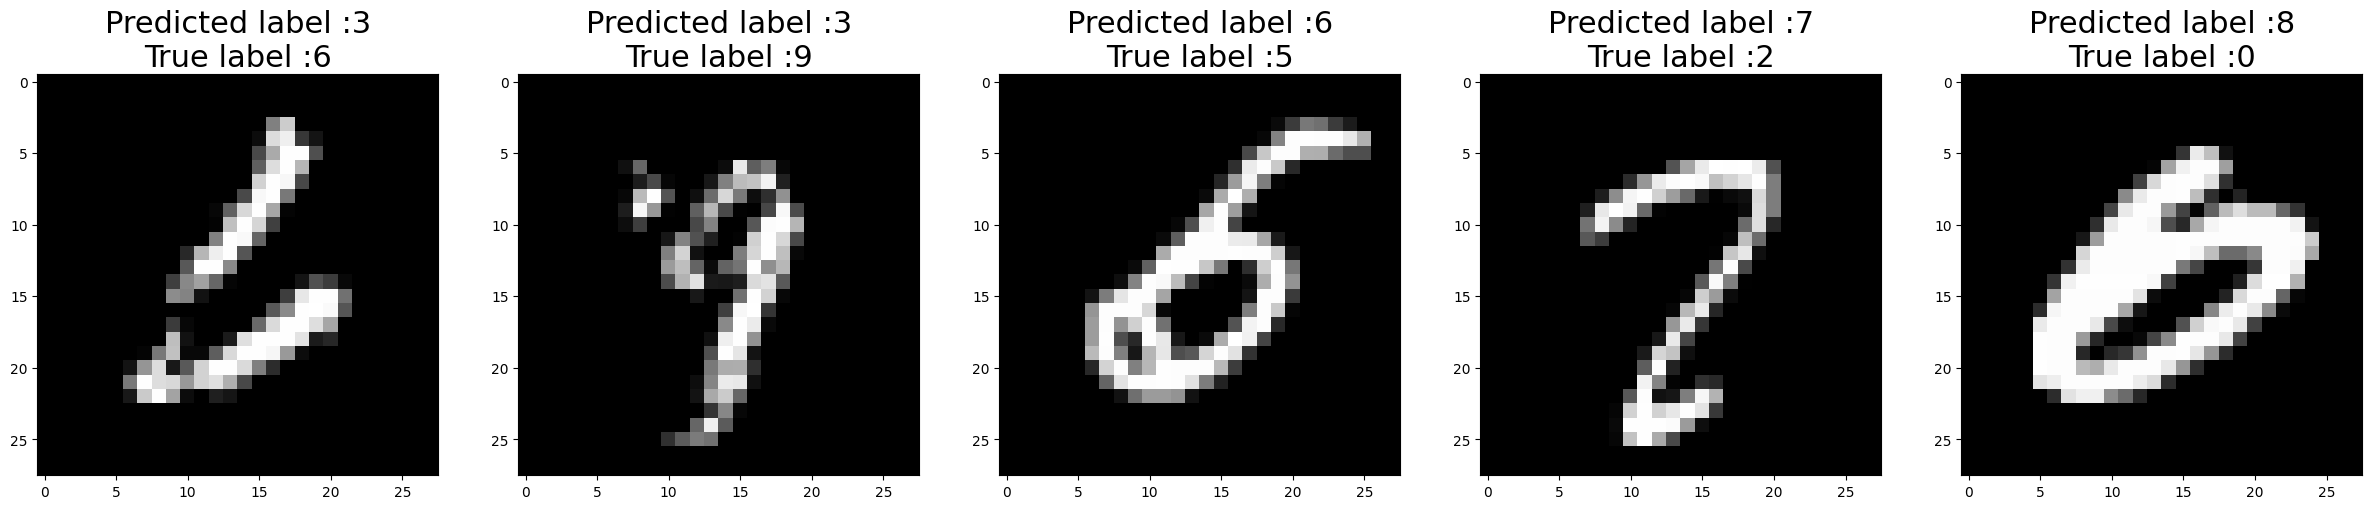

In [ ]:
# Show top errors
num = len(top_idx_diff_errors)
f, ax = plt.subplots(1, num, figsize=(30,30))

for i in range(0, num):
  idx = top_idx_diff_errors[i]
  sample = x_test_errors[idx].reshape(28,28)
  y_t = y_true_errors[idx]
  y_p = y_pred_classes_errors[idx]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title('Predicted label :{}\nTrue label :{}'.format(y_p, y_t), fontsize=22)